# 🌳 Biomass Prediction Model Training

This notebook trains a machine learning model to predict aboveground biomass density using satellite imagery.

**Features:**
- Sentinel-2 optical data (bands + vegetation indices)
- SRTM elevation and slope
- GEDI L4A biomass ground truth

**Improvements:**
- Hyperparameter tuning
- Multiple algorithms (Random Forest, Gradient Boosting)
- Outlier removal
- Feature engineering
- Model stacking ensemble

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import randint, uniform
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## 📊 Load and Explore Data

In [3]:
# Load training data
df = pd.read_csv('/kaggle/input/datasets/orpheusmanga/sentinel/sentinel_gedi_training.csv')

print(f"Dataset shape: {df.shape}")
print(f"Samples: {len(df):,}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nBiomass stats:\n{df['agbd_tonnes_per_ha'].describe()}")

df.head()

Dataset shape: (12000, 17)
Samples: 12,000

Columns: ['lat', 'lon', 'blue', 'green', 'red', 'nir', 'swir1', 'swir2', 'ndvi', 'evi', 'savi', 'ndmi', 'nbr', 'elevation', 'slope', 'n_images', 'agbd_tonnes_per_ha']

Missing values:
lat                   0
lon                   0
blue                  0
green                 0
red                   0
nir                   0
swir1                 0
swir2                 0
ndvi                  0
evi                   0
savi                  0
ndmi                  0
nbr                   0
elevation             0
slope                 0
n_images              0
agbd_tonnes_per_ha    0
dtype: int64

Biomass stats:
count    12000.000000
mean        44.610630
std         47.645214
min          0.970350
25%          7.746116
50%         31.873490
75%         65.039682
max        473.103940
Name: agbd_tonnes_per_ha, dtype: float64


,lat,lon,blue,green,red,nir,swir1,swir2,ndvi,evi,savi,ndmi,nbr,elevation,slope,n_images,agbd_tonnes_per_ha
0,-18.213182,12.769657,1416.000000,1910.750000,2551.333333,2901.000000,3767.000000,3380.00,0.070534,0.126941,0.105792,-0.114111,-0.061160,914,6.767081,95,4.505998
1,-18.186341,12.791609,1252.000000,1733.333333,2294.000000,2668.500000,3782.000000,3527.00,0.074290,0.127493,0.111424,-0.159093,-0.121904,921,2.926229,95,1.171597
2,-18.155809,12.816526,903.500000,1395.250000,2384.500000,2981.750000,4200.500000,3752.25,0.110818,0.142410,0.166211,-0.168397,-0.114123,921,4.032743,154,1.228436
3,-18.151736,12.819844,1289.500000,1830.000000,2694.250000,3168.000000,4088.000000,3594.00,0.079769,0.117760,0.119644,-0.121646,-0.058442,914,3.830497,154,1.630395
4,-18.126067,12.840727,936.555556,1573.840000,2982.333333,3685.454545,5647.380952,5745.55,0.101952,0.118815,0.153437,-0.208293,-0.217382,906,2.159976,211,1.391625


### Visualize Data Distribution

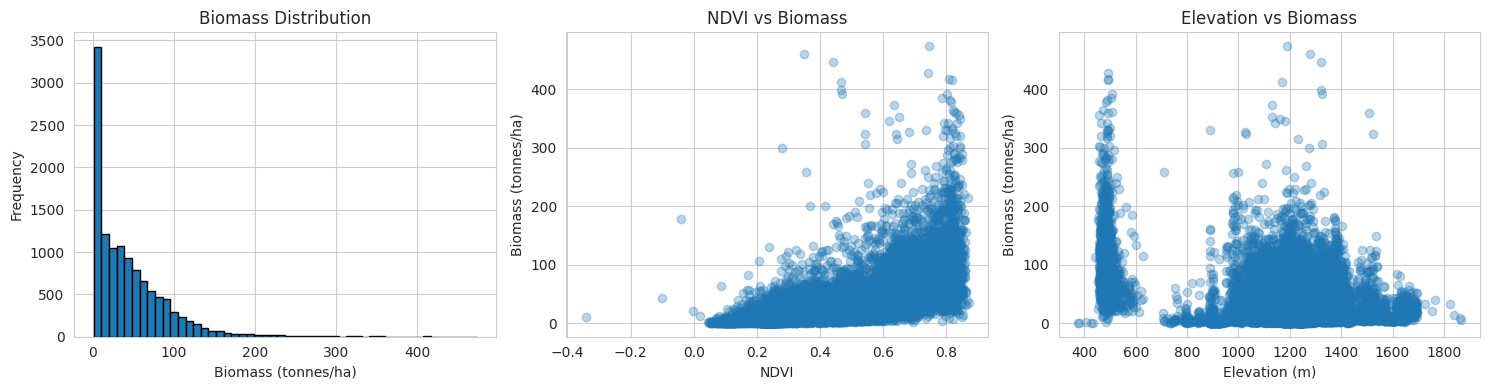

In [4]:
# Plot biomass distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['agbd_tonnes_per_ha'], bins=50, edgecolor='black')
axes[0].set_title('Biomass Distribution')
axes[0].set_xlabel('Biomass (tonnes/ha)')
axes[0].set_ylabel('Frequency')

axes[1].scatter(df['ndvi'], df['agbd_tonnes_per_ha'], alpha=0.3)
axes[1].set_title('NDVI vs Biomass')
axes[1].set_xlabel('NDVI')
axes[1].set_ylabel('Biomass (tonnes/ha)')

axes[2].scatter(df['elevation'], df['agbd_tonnes_per_ha'], alpha=0.3)
axes[2].set_title('Elevation vs Biomass')
axes[2].set_xlabel('Elevation (m)')
axes[2].set_ylabel('Biomass (tonnes/ha)')

plt.tight_layout()
plt.show()

### Feature Correlation

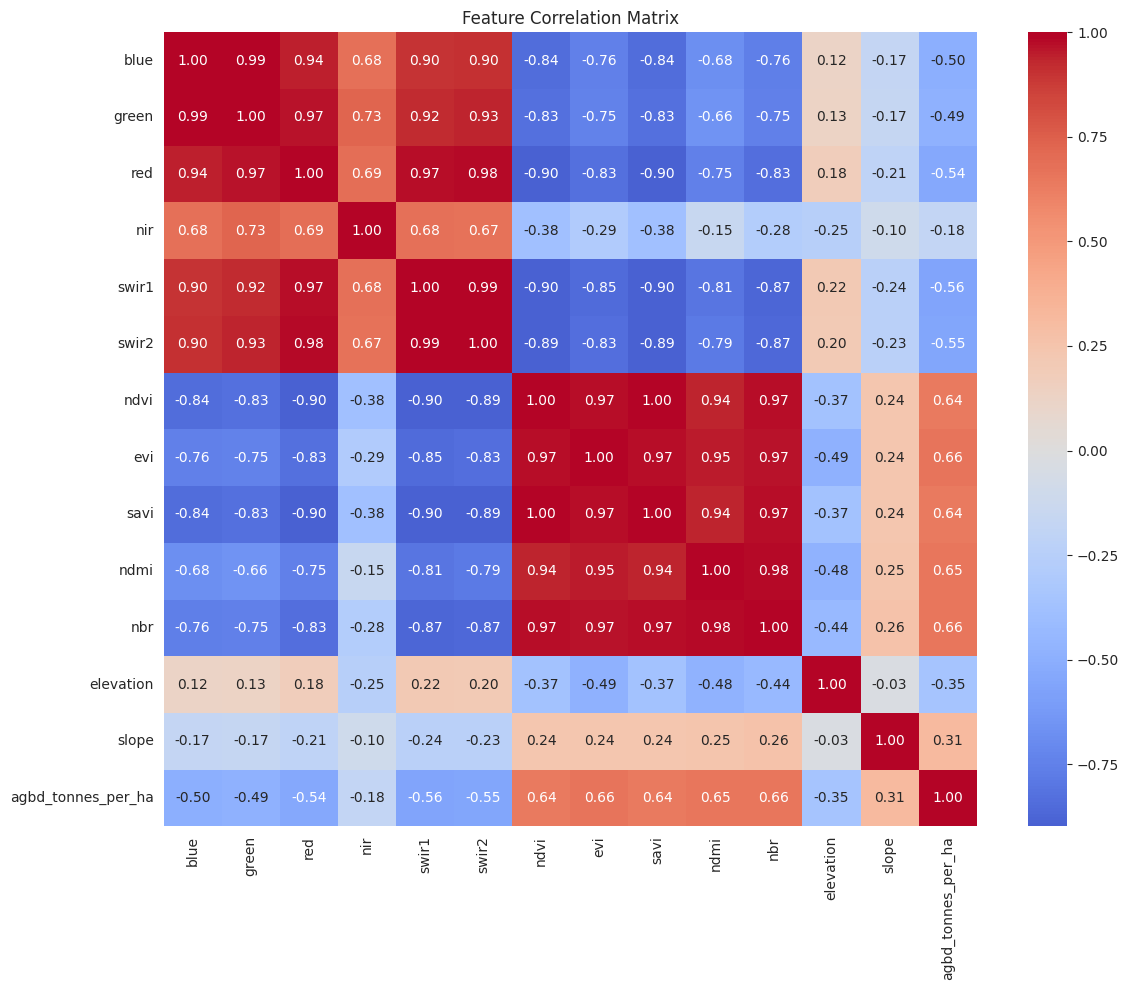


Correlation with biomass:
agbd_tonnes_per_ha    1.000000
evi                   0.663929
nbr                   0.658066
ndmi                  0.652300
savi                  0.641081
ndvi                  0.641074
slope                 0.312929
nir                  -0.182393
elevation            -0.352858
green                -0.490636
blue                 -0.500530
red                  -0.536867
swir2                -0.552703
swir1                -0.563246
Name: agbd_tonnes_per_ha, dtype: float64


In [5]:
# Correlation heatmap
feature_cols = ['blue', 'green', 'red', 'nir', 'swir1', 'swir2', 
                'ndvi', 'evi', 'savi', 'ndmi', 'nbr', 'elevation', 'slope']

corr_matrix = df[feature_cols + ['agbd_tonnes_per_ha']].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print("\nCorrelation with biomass:")
print(corr_matrix['agbd_tonnes_per_ha'].sort_values(ascending=False))

## 🎯 Baseline Model Training

In [6]:
# Prepare data
feature_cols = ['blue', 'green', 'red', 'nir', 'swir1', 'swir2', 
                'ndvi', 'evi', 'savi', 'ndmi', 'nbr', 'elevation', 'slope']

X = df[feature_cols].copy()
y = df['agbd_tonnes_per_ha'].copy()

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set: {X_test.shape[0]:,} samples")

Training set: 9,600 samples
Test set: 2,400 samples


In [7]:
# Train baseline Random Forest
baseline_rf = RandomForestRegressor(
    n_estimators=150,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

baseline_rf.fit(X_train_scaled, y_train)

# Evaluate
y_train_pred = baseline_rf.predict(X_train_scaled)
y_test_pred = baseline_rf.predict(X_test_scaled)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("📊 Baseline Random Forest Performance:")
print(f"  Train R²: {train_r2:.4f}")
print(f"  Test R²: {test_r2:.4f}")
print(f"  Test MAE: {test_mae:.2f} tonnes/ha")
print(f"  Test RMSE: {test_rmse:.2f} tonnes/ha")

# Store baseline results
results = {
    'Model': ['Baseline RF'],
    'Train_R2': [train_r2],
    'Test_R2': [test_r2],
    'MAE': [test_mae],
    'RMSE': [test_rmse]
}

📊 Baseline Random Forest Performance:
  Train R²: 0.6460
  Test R²: 0.5307
  Test MAE: 19.31 tonnes/ha
  Test RMSE: 32.03 tonnes/ha


### Feature Importance

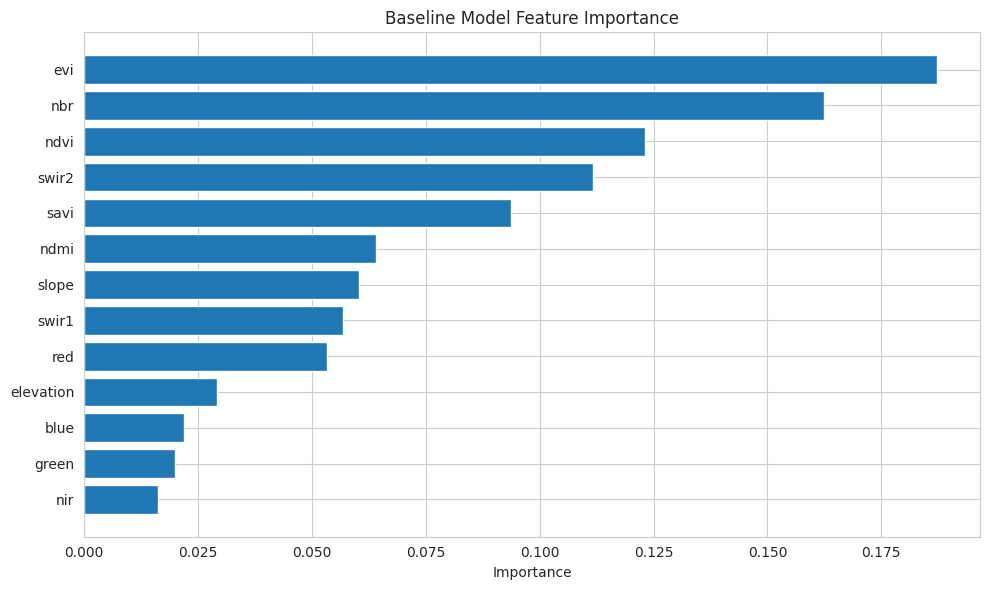


Top 5 features:
   Feature  Importance
7      evi    0.187309
10     nbr    0.162386
6     ndvi    0.123182
5    swir2    0.111653
8     savi    0.093749


In [8]:
# Plot feature importance
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': baseline_rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Baseline Model Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 5 features:")
print(importance_df.head())

## 🚀 Model Improvement Strategies

### Strategy 1: Hyperparameter Tuning

In [9]:
# Define parameter space
param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': randint(10, 30),
    'min_samples_split': randint(10, 50),
    'min_samples_leaf': randint(5, 20),
    'max_features': ['sqrt', 'log2', 0.5, 0.7]
}

# Randomized search
print("🔍 Starting hyperparameter tuning (this may take 10-15 minutes)...")
random_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_scaled, y_train)

print(f"\n✅ Best parameters: {random_search.best_params_}")
print(f"✅ Best CV R²: {random_search.best_score_:.4f}")

# Evaluate tuned model
tuned_rf = random_search.best_estimator_
y_train_pred = tuned_rf.predict(X_train_scaled)
y_test_pred = tuned_rf.predict(X_test_scaled)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"\n📊 Tuned RF Performance:")
print(f"  Train R²: {train_r2:.4f}")
print(f"  Test R²: {test_r2:.4f}")
print(f"  Test MAE: {test_mae:.2f} tonnes/ha")
print(f"  Test RMSE: {test_rmse:.2f} tonnes/ha")

# Store results
results['Model'].append('Tuned RF')
results['Train_R2'].append(train_r2)
results['Test_R2'].append(test_r2)
results['MAE'].append(test_mae)
results['RMSE'].append(test_rmse)

🔍 Starting hyperparameter tuning (this may take 10-15 minutes)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

✅ Best parameters: {'max_depth': 15, 'max_features': 0.7, 'min_samples_leaf': 11, 'min_samples_split': 13, 'n_estimators': 282}
✅ Best CV R²: 0.5111

📊 Tuned RF Performance:
  Train R²: 0.6658
  Test R²: 0.5319
  Test MAE: 18.98 tonnes/ha
  Test RMSE: 31.98 tonnes/ha


### Strategy 2: Gradient Boosting

In [10]:
# Train Gradient Boosting
print("🌲 Training Gradient Boosting model...")
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)

gb_model.fit(X_train_scaled, y_train)

# Evaluate
y_train_pred = gb_model.predict(X_train_scaled)
y_test_pred = gb_model.predict(X_test_scaled)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"\n📊 Gradient Boosting Performance:")
print(f"  Train R²: {train_r2:.4f}")
print(f"  Test R²: {test_r2:.4f}")
print(f"  Test MAE: {test_mae:.2f} tonnes/ha")
print(f"  Test RMSE: {test_rmse:.2f} tonnes/ha")

# Store results
results['Model'].append('Gradient Boosting')
results['Train_R2'].append(train_r2)
results['Test_R2'].append(test_r2)
results['MAE'].append(test_mae)
results['RMSE'].append(test_rmse)

🌲 Training Gradient Boosting model...

📊 Gradient Boosting Performance:
  Train R²: 0.9573
  Test R²: 0.4538
  Test MAE: 20.28 tonnes/ha
  Test RMSE: 34.55 tonnes/ha


### Strategy 3: Outlier Removal

In [11]:
# Remove outliers using IQR method
Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Biomass bounds: [{lower_bound:.1f}, {upper_bound:.1f}] tonnes/ha")

# Create mask
mask = (y_train >= lower_bound) & (y_train <= upper_bound)
X_train_clean = X_train_scaled[mask]
y_train_clean = y_train[mask]

print(f"Outliers removed: {(~mask).sum()} ({(~mask).sum()/len(mask)*100:.1f}%)")
print(f"Clean training set: {X_train_clean.shape[0]:,} samples")

# Train on clean data
clean_rf = RandomForestRegressor(
    n_estimators=150,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

clean_rf.fit(X_train_clean, y_train_clean)

# Evaluate
y_train_pred = clean_rf.predict(X_train_clean)
y_test_pred = clean_rf.predict(X_test_scaled)

train_r2 = r2_score(y_train_clean, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"\n📊 Clean Data RF Performance:")
print(f"  Train R²: {train_r2:.4f}")
print(f"  Test R²: {test_r2:.4f}")
print(f"  Test MAE: {test_mae:.2f} tonnes/ha")
print(f"  Test RMSE: {test_rmse:.2f} tonnes/ha")

# Store results
results['Model'].append('Clean Data RF')
results['Train_R2'].append(train_r2)
results['Test_R2'].append(test_r2)
results['MAE'].append(test_mae)
results['RMSE'].append(test_rmse)

Biomass bounds: [-78.1, 150.6] tonnes/ha
Outliers removed: 317 (3.3%)
Clean training set: 9,283 samples

📊 Clean Data RF Performance:
  Train R²: 0.7325
  Test R²: 0.4917
  Test MAE: 18.95 tonnes/ha
  Test RMSE: 33.33 tonnes/ha


### Strategy 4: Feature Engineering

In [12]:
# Create new features
def add_engineered_features(X_df):
    X_eng = X_df.copy()
    
    # Band ratios
    X_eng['nir_red_ratio'] = X_df['nir'] / (X_df['red'] + 1e-6)
    X_eng['swir1_nir_ratio'] = X_df['swir1'] / (X_df['nir'] + 1e-6)
    X_eng['green_red_ratio'] = X_df['green'] / (X_df['red'] + 1e-6)
    
    # Tasseled Cap Transform components (simplified)
    X_eng['brightness'] = X_df['blue'] + X_df['green'] + X_df['red'] + X_df['nir'] + X_df['swir1'] + X_df['swir2']
    X_eng['greenness'] = -X_df['blue'] - X_df['green'] - X_df['red'] + X_df['nir'] - X_df['swir1'] - X_df['swir2']
    X_eng['wetness'] = X_df['blue'] + X_df['green'] - X_df['nir'] - X_df['swir1'] - X_df['swir2']
    
    # Vegetation index interactions
    X_eng['ndvi_evi_product'] = X_df['ndvi'] * X_df['evi']
    X_eng['ndvi_squared'] = X_df['ndvi'] ** 2
    
    # Topographic interaction
    X_eng['elevation_slope_interaction'] = X_df['elevation'] * X_df['slope']
    
    return X_eng

# Apply feature engineering
X_train_eng = add_engineered_features(pd.DataFrame(X_train, columns=feature_cols))
X_test_eng = add_engineered_features(pd.DataFrame(X_test, columns=feature_cols))

# Scale new features
scaler_eng = StandardScaler()
X_train_eng_scaled = scaler_eng.fit_transform(X_train_eng)
X_test_eng_scaled = scaler_eng.transform(X_test_eng)

print(f"Original features: {X_train.shape[1]}")
print(f"Engineered features: {X_train_eng.shape[1]}")
print(f"New features added: {X_train_eng.shape[1] - X_train.shape[1]}")

# Train with engineered features
eng_rf = RandomForestRegressor(
    n_estimators=150,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

eng_rf.fit(X_train_eng_scaled, y_train)

# Evaluate
y_train_pred = eng_rf.predict(X_train_eng_scaled)
y_test_pred = eng_rf.predict(X_test_eng_scaled)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"\n📊 Engineered Features RF Performance:")
print(f"  Train R²: {train_r2:.4f}")
print(f"  Test R²: {test_r2:.4f}")
print(f"  Test MAE: {test_mae:.2f} tonnes/ha")
print(f"  Test RMSE: {test_rmse:.2f} tonnes/ha")

# Store results
results['Model'].append('Engineered Features RF')
results['Train_R2'].append(train_r2)
results['Test_R2'].append(test_r2)
results['MAE'].append(test_mae)
results['RMSE'].append(test_rmse)

Original features: 13
Engineered features: 22
New features added: 9

📊 Engineered Features RF Performance:
  Train R²: 0.6530
  Test R²: 0.5308
  Test MAE: 19.36 tonnes/ha
  Test RMSE: 32.02 tonnes/ha


### Strategy 5: Stacking Ensemble

In [13]:
# Create stacking ensemble
print("🏗️ Building stacking ensemble...")

base_rf = RandomForestRegressor(
    n_estimators=150,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

base_gb = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)

stacking_model = StackingRegressor(
    estimators=[
        ('rf', base_rf),
        ('gb', base_gb)
    ],
    final_estimator=Ridge(alpha=1.0),
    n_jobs=-1
)

stacking_model.fit(X_train_scaled, y_train)

# Evaluate
y_train_pred = stacking_model.predict(X_train_scaled)
y_test_pred = stacking_model.predict(X_test_scaled)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"\n📊 Stacking Ensemble Performance:")
print(f"  Train R²: {train_r2:.4f}")
print(f"  Test R²: {test_r2:.4f}")
print(f"  Test MAE: {test_mae:.2f} tonnes/ha")
print(f"  Test RMSE: {test_rmse:.2f} tonnes/ha")

# Store results
results['Model'].append('Stacking Ensemble')
results['Train_R2'].append(train_r2)
results['Test_R2'].append(test_r2)
results['MAE'].append(test_mae)
results['RMSE'].append(test_rmse)

🏗️ Building stacking ensemble...

📊 Stacking Ensemble Performance:
  Train R²: 0.7174
  Test R²: 0.5278
  Test MAE: 19.30 tonnes/ha
  Test RMSE: 32.13 tonnes/ha


## 📈 Results Comparison

In [14]:
# Create results dataframe
results_df = pd.DataFrame(results)
results_df['Overfitting_Gap'] = results_df['Train_R2'] - results_df['Test_R2']

print("=" * 80)
print("MODEL COMPARISON")
print("=" * 80)
print(results_df.to_string(index=False))
print("=" * 80)

# Find best model
best_idx = results_df['Test_R2'].idxmax()
best_model = results_df.loc[best_idx, 'Model']
best_r2 = results_df.loc[best_idx, 'Test_R2']
best_mae = results_df.loc[best_idx, 'MAE']

print(f"\n🏆 BEST MODEL: {best_model}")
print(f"   Test R²: {best_r2:.4f}")
print(f"   MAE: {best_mae:.2f} tonnes/ha")

# Calculate improvement
baseline_r2 = results_df.loc[0, 'Test_R2']
improvement = (best_r2 - baseline_r2) / baseline_r2 * 100

print(f"\n📊 Improvement over baseline: {improvement:.1f}%")
print(f"   Baseline R²: {baseline_r2:.4f}")
print(f"   Best R²: {best_r2:.4f}")
print(f"   Gain: +{best_r2 - baseline_r2:.4f}")

MODEL COMPARISON
                 Model  Train_R2  Test_R2       MAE      RMSE  Overfitting_Gap
           Baseline RF  0.645990 0.530654 19.306768 32.027836         0.115336
              Tuned RF  0.665770 0.531922 18.981880 31.984523         0.133848
     Gradient Boosting  0.957281 0.453752 20.281025 34.552220         0.503529
         Clean Data RF  0.732511 0.491719 18.947617 33.329823         0.240792
Engineered Features RF  0.653026 0.530825 19.357683 32.022007         0.122201
     Stacking Ensemble  0.717429 0.527757 19.296037 32.126503         0.189672

🏆 BEST MODEL: Tuned RF
   Test R²: 0.5319
   MAE: 18.98 tonnes/ha

📊 Improvement over baseline: 0.2%
   Baseline R²: 0.5307
   Best R²: 0.5319
   Gain: +0.0013


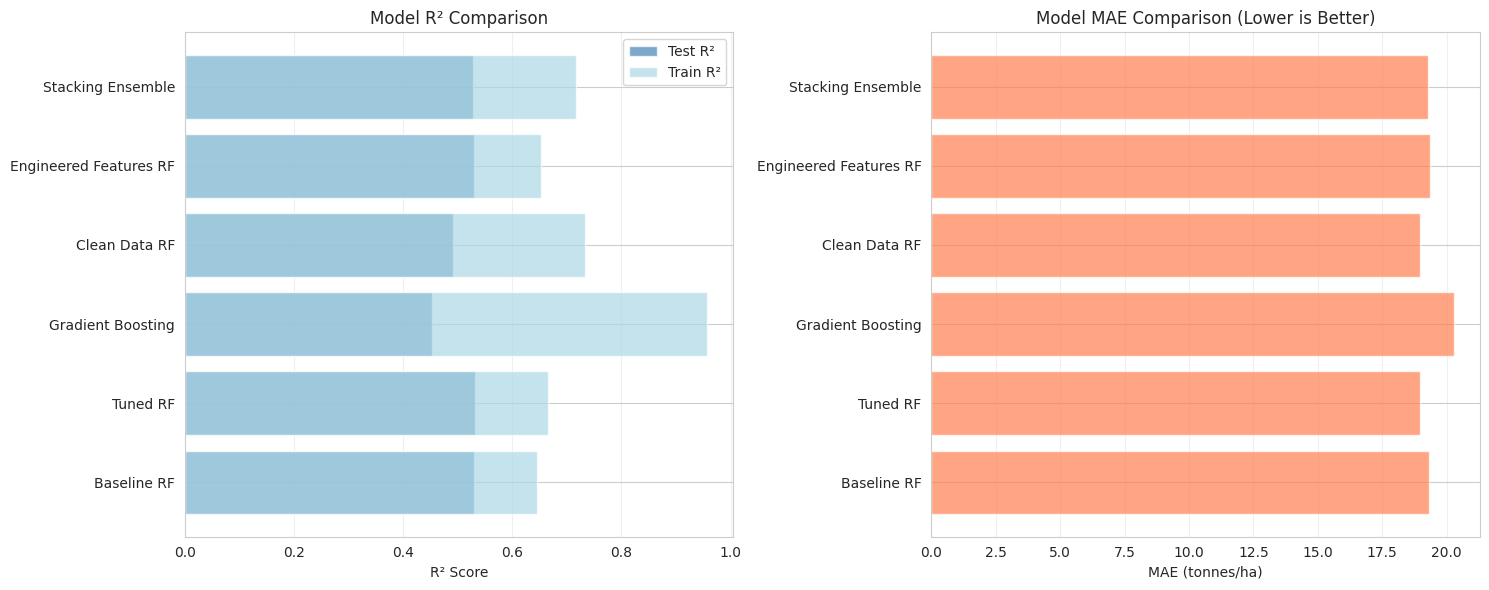

In [15]:
# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# R² comparison
axes[0].barh(results_df['Model'], results_df['Test_R2'], color='steelblue', alpha=0.7, label='Test R²')
axes[0].barh(results_df['Model'], results_df['Train_R2'], color='lightblue', alpha=0.7, label='Train R²')
axes[0].set_xlabel('R² Score')
axes[0].set_title('Model R² Comparison')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

# MAE comparison
axes[1].barh(results_df['Model'], results_df['MAE'], color='coral', alpha=0.7)
axes[1].set_xlabel('MAE (tonnes/ha)')
axes[1].set_title('Model MAE Comparison (Lower is Better)')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 💾 Save Best Model

In [16]:
# Determine which model to save based on best performance
best_model_name = results_df.loc[results_df['Test_R2'].idxmax(), 'Model']

print(f"Saving best model: {best_model_name}")

# Select model and prepare data based on best performer
if best_model_name == 'Baseline RF':
    final_model = baseline_rf
    final_scaler = scaler
    final_features = feature_cols
elif best_model_name == 'Tuned RF':
    final_model = tuned_rf
    final_scaler = scaler
    final_features = feature_cols
elif best_model_name == 'Gradient Boosting':
    final_model = gb_model
    final_scaler = scaler
    final_features = feature_cols
elif best_model_name == 'Clean Data RF':
    final_model = clean_rf
    final_scaler = scaler
    final_features = feature_cols
elif best_model_name == 'Engineered Features RF':
    final_model = eng_rf
    final_scaler = scaler_eng
    final_features = list(X_train_eng.columns)
else:  # Stacking Ensemble
    final_model = stacking_model
    final_scaler = scaler
    final_features = feature_cols

# Create model package
model_data = {
    'model': final_model,
    'scaler': final_scaler,
    'feature_cols': final_features,
    'test_r2': results_df.loc[results_df['Model'] == best_model_name, 'Test_R2'].values[0],
    'test_mae': results_df.loc[results_df['Model'] == best_model_name, 'MAE'].values[0],
    'test_rmse': results_df.loc[results_df['Model'] == best_model_name, 'RMSE'].values[0],
    'training_samples': len(X_train)
}

# Save model
joblib.dump(model_data, 'biomass_model_v2_improved.pkl')

print(f"\n✅ Model saved as 'biomass_model_v2_improved.pkl'")
print(f"\nModel Details:")
print(f"  Algorithm: {best_model_name}")
print(f"  Test R²: {model_data['test_r2']:.4f}")
print(f"  MAE: {model_data['test_mae']:.2f} tonnes/ha")
print(f"  RMSE: {model_data['test_rmse']:.2f} tonnes/ha")
print(f"  Features: {len(final_features)}")
print(f"  Training samples: {model_data['training_samples']:,}")

Saving best model: Tuned RF

✅ Model saved as 'biomass_model_v2_improved.pkl'

Model Details:
  Algorithm: Tuned RF
  Test R²: 0.5319
  MAE: 18.98 tonnes/ha
  RMSE: 31.98 tonnes/ha
  Features: 13
  Training samples: 9,600


## 📝 Next Steps

### Further Improvements:
1. **Kenya-Specific Data**: Collect samples from Kenya highlands for better domain adaptation (+0.10-0.15 R²)
2. **GEDI Canopy Height**: Add L2A canopy height features (+0.05-0.08 R²)
3. **Multi-Temporal Features**: Add seasonal composites (dry/wet season) (+0.03-0.05 R²)
4. **XGBoost**: Try XGBoost algorithm which often outperforms sklearn GradientBoosting (+0.02-0.04 R²)
5. **Deep Learning**: Consider U-Net or ResNet for spatial context if working with image patches

### To Deploy:
```bash
# Copy improved model to production
cp biomass_model_v2_improved.pkl biomass_model_v1.pkl

# Restart backend server
cd /Users/cococe/Desktop/terrafoma/backend
source ../.venv/bin/activate
uvicorn main:app --reload --port 8002
```